In [1]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 29.2 MB/s eta 0:00:00


In [148]:
# Created following to the lessons of Karina Data Scientist [YouTube @https://www.youtube.com/@karinadatascientist]
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
import pmdarima as pm
from pmdarima import auto_arima
from google.colab import drive
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [149]:
sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams['figure.figsize'] = (14, 6)

In [150]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
rohitsahoo_sales_forecasting_df = pd.read_csv('rohitsahoo-sales-forecasting.csv')

In [7]:
rohitsahoo_sales_forecasting_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [8]:
rohitsahoo_sales_forecasting_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [9]:
rohitsahoo_sales_forecasting_df['Order Date'] = pd.to_datetime(rohitsahoo_sales_forecasting_df['Order Date'], format = '%d/%m/%Y')

In [10]:
monthly_sales = rohitsahoo_sales_forecasting_df.groupby(pd.Grouper(key = 'Order Date', freq = 'ME'))['Sales'].sum()

In [63]:
adf_test = adfuller(monthly_sales)

In [74]:
print(f"ADF Statistics: {adf_test[0]:.5f}")
print(f"p-value: {adf_test[1]:.5f}")
for key, value in adf_test[4].items():
  print(f"Critical Value ({key}): [{value:.5f}]")

ADF Statistics: -4.41614
p-value: 0.00028
Critical Value (1%): [-3.57785]
Critical Value (5%): [-2.92534]
Critical Value (10%): [-2.60077]


In [11]:
monthly_sales.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


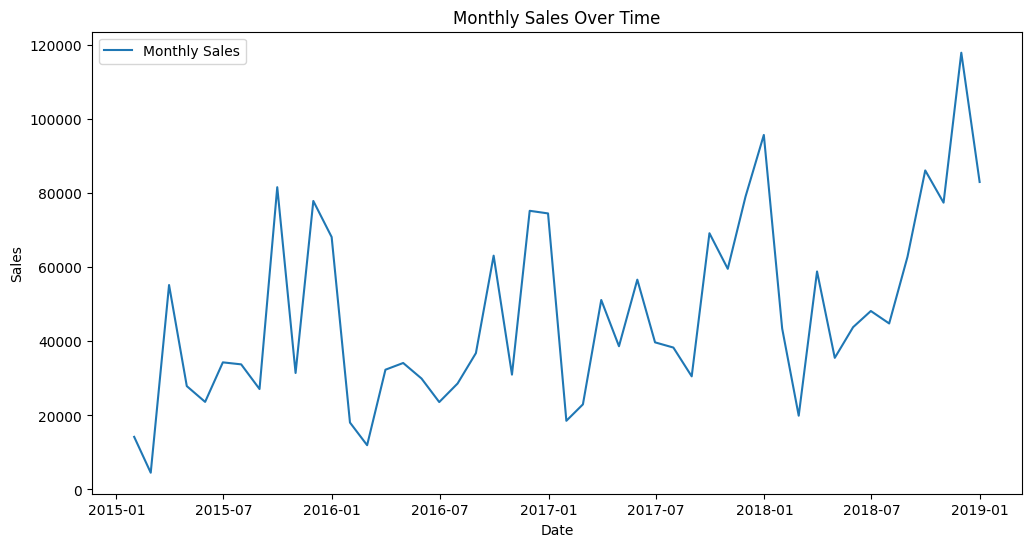

In [12]:
plt.figure(figsize = (12, 6))
plt.plot(monthly_sales, label = 'Monthly Sales')
plt.title('Monthly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

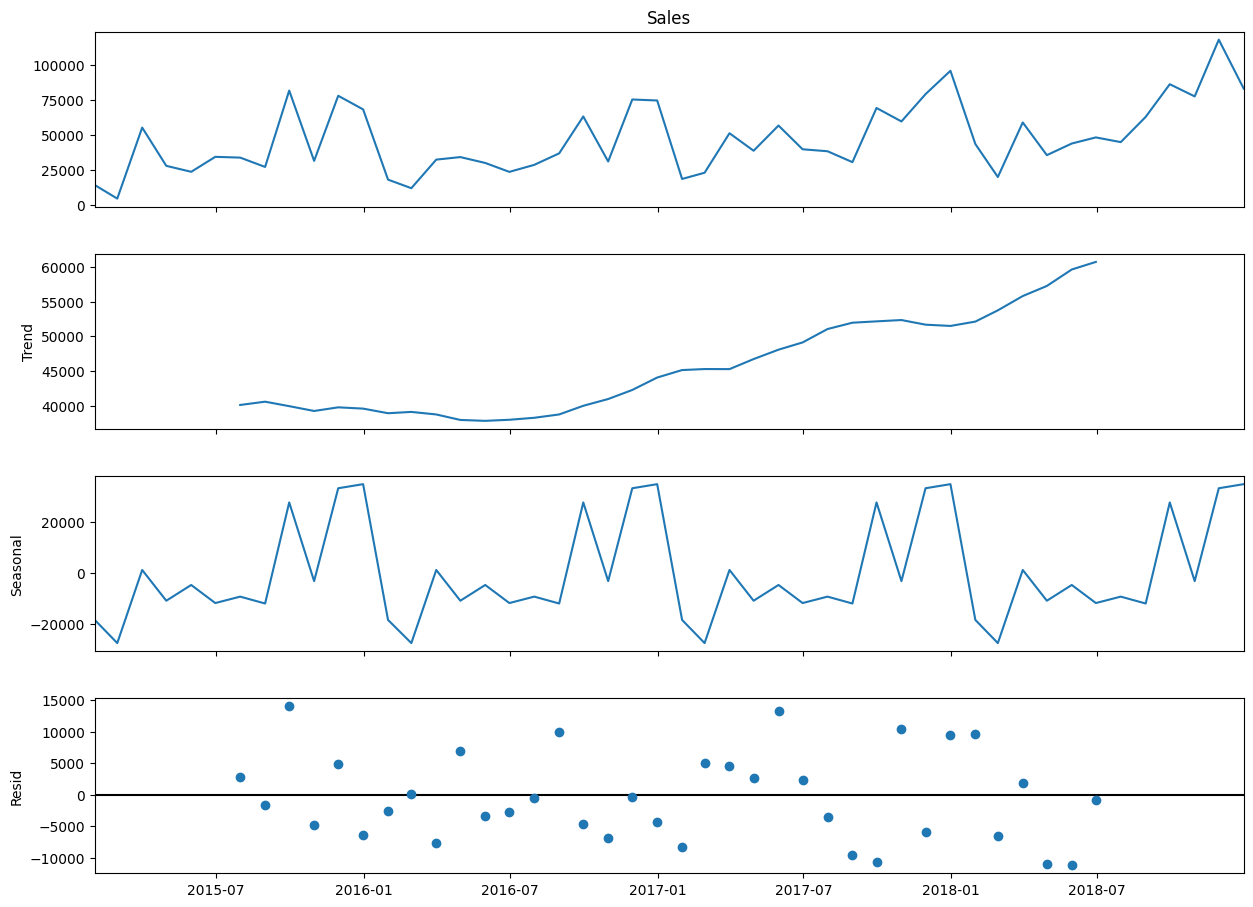

In [13]:
decomposition = seasonal_decompose(monthly_sales, model = 'addictive')
fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.show()

In [162]:
def check_stationarity(timeseries):
    result = adfuller(timeseries)
    print('Augmented Dickey-Fuller Test Results:\n')
    print('ADF Statistics:', result[0])
    print('P-value', result[1])
    print('\nCritical Values:')
    for key, value in result[4].items():
        print(f"\t{key}: {value}")
    return result[1] < 0.05

is_stationary = check_stationarity(monthly_sales)
print(f"\nTime series is {'stationary' if is_stationary else 'non-stationary'}.")

Augmented Dickey-Fuller Test Results:

ADF Statistics: -4.416136761430769
P-value 0.00027791039276670623

Critical Values:
	1%: -3.5778480370438146
	5%: -2.925338105429433
	10%: -2.6007735310095064

Time series is stationary.


In [160]:
def print_adfuller_results(series, significance_level = 0.05):
    print("Results of the Augmented Dickey-Fuller (ADF) Test:\n")

    adf_test = adfuller(series, autolag = 'AIC')

    print(f"Dickey-Fuller (ADF) Test Statistics: {adf_test[0]:.5f}")
    print(f"P-value: {adf_test[1]:.5f}\n")
    print("Critical Values:\n")

    for key, value in adf_test[4].items():
        print(f"{key}: {value:.5f}")
    if adf_test[1] <= significance_level:
        print("\nConclusion: The series is statiinary, we reject the null hypothesis.")
    else:
        print("\nConclusion: The series is not statiinary,e cannot reject the null hypothesis.")
        print("\nRecommendation: Apply differentiation before building an ARIMA model.")
print_adfuller_results(monthly_sales)

Results of the Augmented Dickey-Fuller (ADF) Test:

Dickey-Fuller (ADF) Test Statistics: -4.41614
p-value: 0.00028

Critical Values:

1%: -3.57785
5%: -2.92534
10%: -2.60077

Conclusion: The series is statiinary, we reject the null hypothesis.


In [25]:
model = pm.auto_arima(
    monthly_sales,
    seasonal = True,
    m = 12,
    stepwise = True,
    suppress_warnings = True,
    error_action="ignore"
)

In [27]:
n_periods = 12
forecast, conf_int = model.predict(n_periods=n_periods, return_conf_int = True)
last_date = monthly_sales.index[-1]
forecast_index = pd.date_range(start=last_date + pd.DateOffset(months = 1), periods = n_periods, freq = 'ME')

In [29]:
train_data = monthly_sales.iloc[:-12]
test_data = monthly_sales.iloc[-12:]

In [31]:
eval_model = pm.auto_arima(
    train_data,
    seasonal = True,
    m = 12,
    stepwise = True,
    suppress_warnings = True
)

In [33]:
predictions = eval_model.predict(n_periods = len(test_data))
mae = mean_absolute_error(test_data, predictions)
mse = mean_squared_error(test_data, predictions)
rmse = np.sqrt(mse)
moving_avg = monthly_sales.rolling(window = 3).mean()

In [56]:
print("Model Evaluation Results:\n")
print(f"MAE (Mean Absolute Error): {mae:.4f}")
print(f"MSE (Mean Square Error): {mse:.4f}")
print(f"RMSE (Root of the Mean Square Error): {rmse:.4f}")

Model Evaluation Results:

MAE (Mean Absolute Error): 17909.7571
MSE (Mean Square Error): 563206448.7616
RMSE (Root of the Mean Square Error): 23731.9710


In [83]:
train_size = int(len(monthly_sales) * 0.8)
train, test = monthly_sales[:train_size], monthly_sales[train_size:]

In [84]:
print(f"The size of the training sample: {len(train)}")
print(f"The size of the test sample: {len(test)}")

The size of the training sample: 38
The size of the test sample: 10


In [85]:
arima_model = auto_arima(
    train,
    seasonal = True,
    m = 12,
    trace = True,
    error_action = 'ignore',
    suppress_warnings = True,
    stepwise = True
)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=866.928, Time=1.34 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=873.210, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=867.255, Time=0.12 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=865.014, Time=0.14 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=928.679, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=872.991, Time=0.04 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=866.356, Time=0.14 sec
 ARIMA(0,0,1)(0,0,2)[12] intercept   : AIC=863.723, Time=0.20 sec
 ARIMA(0,0,1)(1,0,2)[12] intercept   : AIC=865.594, Time=0.24 sec
 ARIMA(0,0,0)(0,0,2)[12] intercept   : AIC=864.184, Time=0.27 sec
 ARIMA(1,0,1)(0,0,2)[12] intercept   : AIC=865.520, Time=0.47 sec
 ARIMA(0,0,2)(0,0,2)[12] intercept   : AIC=866.139, Time=1.19 sec
 ARIMA(1,0,0)(0,0,2)[12] intercept   : AIC=863.949, Time=0.86 sec
 ARIMA(1,0,2)(0,0,2)[12] intercept   : AIC=867.851, Time=1.77 sec
 ARIMA(0,0,1)(0,0,2)[12]         

In [119]:
arima_model_1 = auto_arima(
    train,
    start_p = 0, max_p = 3,
    d = 0, max_d = 0,
    start_q = 0, max_q = 3,
    seasonal = False,
    trace = True,
    error_action = 'ignore',
    suppress_warnings = True,
    stepwise = True
)

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=928.679, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=886.339, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=913.500, Time=0.03 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=884.930, Time=0.04 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=883.514, Time=0.06 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=882.460, Time=0.30 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=880.567, Time=0.17 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=879.994, Time=0.11 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=881.264, Time=0.29 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=912.065, Time=0.07 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.22 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=875.162, Time=0.06 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=872.991, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=873.210, Time=0.02 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=874.971, 

In [117]:
print(arima_model.summary())

                                        SARIMAX Results                                        
Dep. Variable:                                       y   No. Observations:                   38
Model:             SARIMAX(0, 0, 1)x(0, 0, [1, 2], 12)   Log Likelihood                -426.862
Date:                                 Sat, 01 Aug 2026   AIC                            863.723
Time:                                         17:16:50   BIC                            871.911
Sample:                                     01-31-2015   HQIC                           866.637
                                          - 02-28-2018                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   4.272e+04   9328.159      4.579      0.000    2.44e+04     6.1

In [120]:
print(arima_model_1.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   38
Model:               SARIMAX(0, 0, 1)   Log Likelihood                -433.495
Date:                Sat, 01 Aug 2026   AIC                            872.991
Time:                        17:17:15   BIC                            877.903
Sample:                    01-31-2015   HQIC                           874.739
                         - 02-28-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   4.272e+04   4342.572      9.836      0.000    3.42e+04    5.12e+04
ma.L1          0.2628      0.144      1.824      0.068      -0.020       0.545
sigma2      4.628e+08      0.074   6.29e+09      0.0

In [88]:
arima_forecast = arima_model.predict(n_periods = len(test))
arima_forecast.index = test.index

In [89]:
holt_winters_model = ExponentialSmoothing(
    train,
    seasonal = 'add',
    seasonal_periods = 12,
    trend = 'add'
).fit()

In [93]:
holt_winters_forecast = holt_winters_model.forecast(len(test))

In [99]:
arima_mae = mean_absolute_error(test, arima_forecast)
arima_mse = mean_squared_error(test, arima_forecast)
holt_winters_mae = mean_absolute_error(test, holt_winters_forecast)
holt_winters_mse = mean_squared_error(test, holt_winters_forecast)

In [109]:
print(f"ARIMA: [MAE]: ({arima_mae:.2f}), [MSE]: ({arima_mse:.2f})")
print(f"Holt-Winters: [MAE]: ({holt_winters_mae:.2f}), [MSE]: ({holt_winters_mse:.2f})")

ARIMA: [MAE]: (20136.83), [MSE]: (665814047.88)
Holt-Winters: [MAE]: (11270.66), [MSE]: (158942454.22)


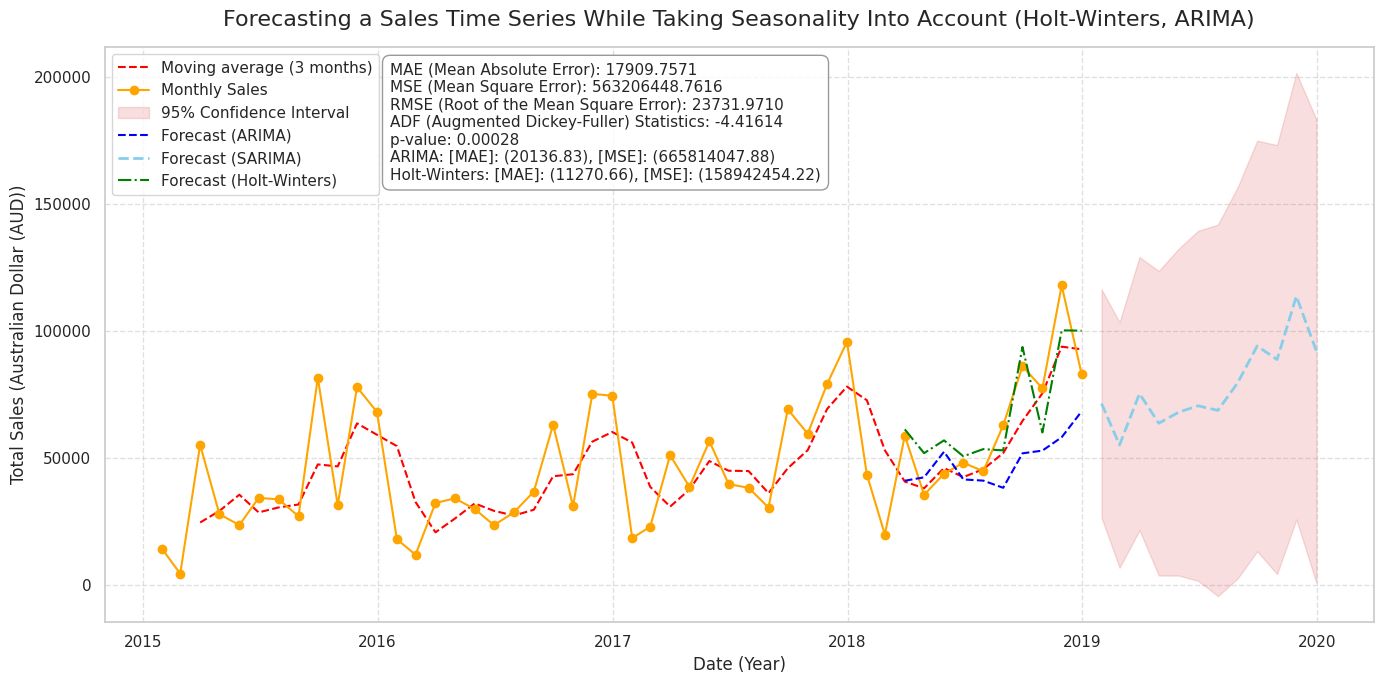

In [174]:
plt.figure(figsize = (14, 7))
plt.plot(monthly_sales.index, moving_avg, label = 'Moving average (3 months)', color = 'red', linestyle = '--')
plt.plot(monthly_sales.index, monthly_sales.values, label='Monthly Sales', marker = 'o', color = 'orange')
plt.fill_between(
    forecast_index,
    conf_int[:, 0],
    conf_int[:, 1],
    color = '#d62728',
    alpha = 0.15,
    label = '95% Confidence Interval'
)
plt.plot(arima_forecast.index, arima_forecast, label = 'Forecast (ARIMA)', linestyle = '--', color = 'blue')
plt.plot(forecast_index, forecast, label  ='Forecast (SARIMA)', linestyle = '--', linewidth = 2, color = 'skyblue')
plt.plot(holt_winters_forecast.index, holt_winters_forecast, label = 'Forecast (Holt-Winters)', linestyle = '-.', color = 'green')
plt.text(
    0.225,
    0.972,
    "MAE (Mean Absolute Error): 17909.7571\nMSE (Mean Square Error): 563206448.7616\nRMSE (Root of the Mean Square Error): 23731.9710\nADF (Augmented Dickey-Fuller) Statistics: -4.41614\np-value: 0.00028\nARIMA: [MAE]: (20136.83), [MSE]: (665814047.88)\nHolt-Winters: [MAE]: (11270.66), [MSE]: (158942454.22)",
    transform = plt.gca().transAxes,
    fontsize = 11,
    verticalalignment = 'top',
    bbox = dict(boxstyle = 'round, pad = 0.5', facecolor = 'white', alpha = 0.8, edgecolor = 'gray')
)
plt.title('Forecasting a Sales Time Series While Taking Seasonality Into Account (Holt-Winters, ARIMA)', fontsize = 16, pad = 15)
plt.xlabel('Date (Year)', fontsize = 12)
plt.ylabel('Total Sales (Australian Dollar (AUD))', fontsize = 12)
plt.legend(loc = 'upper left', fontsize = 11)
plt.grid(True, linestyle = '--', alpha = 0.6)
plt.tight_layout()
plt.show()